# iNat ↔ Wikidata taxon matching — report

Results, negative-sampling story, and error analysis. See `docs/inat-wikidata-match-spec.md`.

This notebook is populated incrementally, one section per milestone (spec §7), as each lands —
not written retroactively at the end.

## Milestone 1 — Ingest

Read `~/.cache/wikidata-inat-checker/taxa.db` (built by the sibling
[wikidata-inat-checker](https://github.com/Livia-Rasp/wikidata-inat-checker) repo) read-only,
and build a cached normalised-name + FTS5 trigram lookup table from it. See `src/normalize.py`
and `src/candidates.py`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from src.candidates import (
    build_lookup_cache,
    lookup_by_normalized_name,
    DEFAULT_TAXA_DB_PATH,
    DEFAULT_CACHE_PATH,
)
from src.normalize import normalize_name

conn = build_lookup_cache()
print(f"taxa index:   {DEFAULT_TAXA_DB_PATH}")
print(f"lookup cache: {DEFAULT_CACHE_PATH}")

taxa index:   /home/livia/.cache/wikidata-inat-checker/taxa.db
lookup cache: /home/livia/repos/xgboost-inat-wikidata-match/data/lookup.sqlite


### Corpus size and rank distribution

Confirms the index matches what the ingest exploration found: 1.4M active taxa, `rank_level`
and `active` not persisted (dropped by the Node builder — flagged as a gap to close in
milestone 4, features).

In [2]:
total = conn.execute("SELECT COUNT(*) FROM taxa_normalized").fetchone()[0]
print(f"{total:,} taxa in the index\n")
print(f"{'rank':15s}count")
for rank, n in conn.execute(
    "SELECT rank, COUNT(*) c FROM taxa_normalized GROUP BY rank ORDER BY c DESC LIMIT 10"
):
    print(f"{rank:15s}{n:,}")

1,418,443 taxa in the index

rank           count
species        1,116,164
genus          143,042
subspecies     87,842
variety        18,859
family         10,719
subgenus       6,896
hybrid         6,518
tribe          6,070
subfamily      5,472
section        4,842


### The hemihomonym check (milestone 1's acceptance test)

`Prunella` names both a bird genus (accentors, Prunellidae) and a mint genus (self-heal,
Lamiaceae). Name-only matching can't tell them apart — only ancestry can. This is exactly the
case candidate strategy 1 (spec §2) must surface both candidates for, rather than stopping at
the first hit.

In [3]:
matches = lookup_by_normalized_name(conn, "prunella")
print(f"{len(matches)} match(es) for 'prunella':")
for row in matches:
    print(f"  {row}")

2 match(es) for 'prunella':
  {'taxon_id': '13982', 'name': 'Prunella', 'rank': 'genus', 'ancestry': '48460/1/2/355675/3/7251/71358'}
  {'taxon_id': '52765', 'name': 'Prunella', 'rank': 'genus', 'ancestry': '48460/47126/211194/47125/47124/48151/48623/520502/918917/919181'}


### Name normalisation examples (spec §1)

Authorship stripping, infraspecific connectors, hybrid markers, and the gender-stripped epithet
stem — the last of these is what makes `Acer rubrum` / `Acer ruber` collapse to the same stem
despite disagreeing on gender.

In [4]:
cases = [
    "Rosa canina L.",
    "Acer rubrum",
    "Acer ruber",
    "Rosa canina subsp. dumetorum",
    "Salix x sepulcralis",
    "\u00d7Fragaria",
    "Bellis perennis (L.) DC.",
]
for c in cases:
    n = normalize_name(c)
    print(f"{c!r:35} -> {n.normalized!r:35} stem={n.epithet_stem!r:12} hybrid={n.hybrid}")

'Rosa canina L.'                    -> 'rosa canina'                       stem='canin'      hybrid=False
'Acer rubrum'                       -> 'acer rubrum'                       stem='rubr'       hybrid=False
'Acer ruber'                        -> 'acer ruber'                        stem='rubr'       hybrid=False
'Rosa canina subsp. dumetorum'      -> 'rosa canina subsp dumetorum'       stem='canin'      hybrid=False
'Salix x sepulcralis'               -> 'salix sepulcralis'                 stem='sepulcral'  hybrid=True
'×Fragaria'                         -> 'fragaria'                          stem=None         hybrid=True
'Bellis perennis (L.) DC.'          -> 'bellis perennis'                   stem='perenn'     hybrid=False


### Observation: how much genuine name-collision exists, and one normalisation gap it surfaced

48,280 normalised names (3.4% of the index) are shared by 2+ taxa — the raw material for
hemihomonym-style ambiguity that candidate generation and the taxonomic-agreement features
(spec §4) need to resolve.

But the single most-duplicated name, `cortinarius` (501 rows), isn't really 501 genuine
homonyms — it's a normalisation gap. Provisional/unresolved iNat species like `Cortinarius sp.
'AZ19'` fail the authorship-boundary heuristic in `normalize.py` at `sp.` and get truncated back
to just the genus, `cortinarius`, colliding with the real genus-rank entry and each other. This
doesn't affect the milestone 1 acceptance check, but it inflates the homonym-group count above
and is worth a real decision before milestone 3 (candidate generation): either teach
`normalize.py` to recognise and drop provisional-name taxa specifically, or filter `sp.`/quoted
provisional epithets out of candidate generation entirely, since they have no stable Wikidata
counterpart to match against anyway.

In [5]:
homonym_groups = conn.execute(
    """
    SELECT COUNT(*) FROM (
        SELECT normalized_name FROM taxa_normalized GROUP BY normalized_name HAVING COUNT(*) > 1
    )
    """
).fetchone()[0]
print(f"{homonym_groups:,} normalized names shared by 2+ taxa ({homonym_groups/total:.1%} of the index)")

dup = conn.execute(
    """
    SELECT normalized_name, COUNT(*) c FROM taxa_normalized
    GROUP BY normalized_name HAVING c > 1 ORDER BY c DESC LIMIT 5
    """
).fetchall()
print("most-duplicated normalized names:", dup)

sample = conn.execute(
    "SELECT taxon_id, name, rank FROM taxa_normalized WHERE normalized_name='cortinarius' AND rank='species' LIMIT 3"
).fetchall()
print("sample of what's actually behind 'cortinarius':", sample)

48,280 normalized names shared by 2+ taxa (3.4% of the index)
most-duplicated normalized names: [('cortinarius', 501), ('hygrocybe', 216), ('ramaria', 176), ('inocybe', 167), ('amanita', 161)]
sample of what's actually behind 'cortinarius': [('1666456', "Cortinarius sp. 'AZ19'", 'species'), ('1668233', "Cortinarius sp. 'PNW101'", 'species'), ('1662842', "Cortinarius sp. 'IN10'", 'species')]


## Milestone 2 — Wikidata pull

Batched SPARQL against `https://query.wikidata.org/sparql` for Wikidata taxa carrying P3151
(iNat taxon ID), `LIMIT`-capped to the spec's target size and cached to parquet. See
`src/wikidata.py`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from src.wikidata import build_pull_cache, DEFAULT_CACHE_PATH, DEFAULT_TARGET_SIZE

result = build_pull_cache()
print(f"target size:  {DEFAULT_TARGET_SIZE:,}")
print(f"cache:        {DEFAULT_CACHE_PATH}")
print(f"cache hit:    {result.cache_hit}")
print(f"rows pulled:  {len(result.taxa):,}")

target size:  60,000
cache:        /home/livia/repos/xgboost-inat-wikidata-match/data/wikidata_taxa.parquet
cache hit:    True
rows pulled:  58,064

### How much of Wikidata's P3151 population this actually covers

A live `COUNT` against the endpoint, for context on how small a slice the spec's 30k–60k target
size actually is.

In [2]:
from src.wikidata import _sparql_get_tsv

rows = _sparql_get_tsv(
    "SELECT (COUNT(?item) AS ?count) WHERE { ?item wdt:P31 wd:Q16521 . ?item wdt:P3151 ?inatId . }"
)
total_p3151 = int(rows[0]["count"])
print(f"{total_p3151:,} Wikidata items are taxa with P3151 set")
print(f"pulled {len(result.taxa):,} ({len(result.taxa)/total_p3151:.1%} of the total)")

856,040 Wikidata items are taxa with P3151 set
pulled 58,064 (6.8% of the total)

### Observation: most P3151 links carry no reference

Spec §3 flags that a chunk of P3151 statements were bot-added by exact-name matching, so
"ground truth" is partly the baseline this project is trying to beat, and its stated mitigation
is to prefer referenced statements. Checking reference presence turned up something starker than
"a chunk": **99.66% of pulled statements have no reference at all.** That's not itself proof any
particular link is wrong — most are presumably fine — but it means the reference-presence signal
alone can't carry much of the noise-mitigation weight `labels.py` will need later; the "hand-check
a random sample of 100" step spec §3 also calls for is doing most of the real work.

`has_commons_cat` and `has IUCN status` rates are shown for the same reason milestone 1's report
carries corpus stats: sanity-checking the pull before anything is built on top of it.

In [3]:
df = result.taxa
n = len(df)
print(f"{n:,} rows in the cache\n")
print(f"reference rate:   {df['p3151_has_reference'].sum():,}/{n:,} ({df['p3151_has_reference'].mean():.2%})")
print(f"commons cat rate: {df['has_commons_cat'].sum():,}/{n:,} ({df['has_commons_cat'].mean():.1%})")
print(f"has IUCN status:  {n - df['iucn_qid'].isna().sum():,}/{n:,} ({(1 - df['iucn_qid'].isna().mean()):.1%})")
print()
print("top rank_qid values (raw QID; label resolution deferred to milestone 4):")
print(df["rank_qid"].value_counts().head(6).to_string())

58,064 rows in the cache

reference rate:   198/58,064 (0.34%)
commons cat rate: 15,513/58,064 (26.7%)
has IUCN status:  18,395/58,064 (31.7%)

top rank_qid values (raw QID; label resolution deferred to milestone 4):
rank_qid
Q7432      46516
Q34740      6954
Q68947      2423
Q35409       856
Q767728      807
Q36602       172

### Cross-check against milestone 1's iNat index

Confirms the two caches actually join: each pulled `inat_id` should resolve to the same taxon
name in `data/lookup.sqlite`.

In [4]:
import sqlite3

conn_inat = sqlite3.connect("../data/lookup.sqlite")
sample = df[["qid", "inat_id", "name"]].head(3)
for _, row in sample.iterrows():
    inat_row = conn_inat.execute(
        "SELECT taxon_id, name, rank FROM taxa_normalized WHERE taxon_id=?", (row["inat_id"],)
    ).fetchone()
    print(f"{row['qid']} ({row['name']!r}) -> iNat taxon_id {row['inat_id']}: {inat_row}")

Q557493 ('Melanerpes uropygialis') -> iNat taxon_id 18161: ('18161', 'Melanerpes uropygialis', 'species')
Q569535 ('Melanerpes carolinus') -> iNat taxon_id 18205: ('18205', 'Melanerpes carolinus', 'species')
Q1263378 ('Odontophorus leucolaemus') -> iNat taxon_id 1371: ('1371', 'Odontophorus leucolaemus', 'species')

## Milestone 3 — Candidate generation

The five strategies from spec §2 (exact normalised-name match, genus-fixed/epithet-fuzzy,
epithet-fixed/genus-fuzzy, trigram top-10, synonym/basionym), unioned and capped at K=20 per
Wikidata item. See `src/candidates.py`.

Two real problems surfaced and fixed while building this, both live-verified against the actual
data rather than assumed:

- **FTS5 trigram matching**: OR-joining every individual 3-gram of a query (the direct reading of
  spec §2's "trigram similarity") is correct but ~550ms/query against the 1.4M-row index — nearly
  9 hours for the full pull. OR-joining a handful of overlapping 6-character chunks instead (still
  trigram-tokenized internally, just as contiguous runs) cut that to single-digit milliseconds
  *and* ranked better, since a typo in one chunk still leaves neighbouring chunks intact.
- **The K=20 cap had a bug**: candidates were meant to be capped at 20 per item, but the initial
  implementation always kept *all* exact-normalised-name matches even beyond 20 — up to 55 for a
  few large name collisions. Fixed to truncate the exact-match set by similarity too when it alone
  exceeds K, so every item's candidate set is genuinely bounded at 20.

In [1]:
import sys
from pathlib import Path
import time

sys.path.insert(0, str(Path.cwd().parent))

from src.candidates import build_lookup_cache, build_candidates_cache, DEFAULT_CACHE_PATH, recall_at_k, recall_ceiling_report
from src.wikidata import build_pull_cache, DEFAULT_CACHE_PATH as WIKIDATA_PARQUET_PATH

conn = build_lookup_cache()
wd = build_pull_cache().taxa

start = time.monotonic()
candidates = build_candidates_cache(wd, wikidata_parquet_path=WIKIDATA_PARQUET_PATH)
elapsed = time.monotonic() - start
print(f"{len(candidates):,} candidate rows for {wd['qid'].nunique():,} Wikidata items ({elapsed:.1f}s, cache hit if this repeats)")

590,671 candidate rows for 58,874 Wikidata items (0.4s, cache hit if this repeats)

### The recall ceiling (milestone 3's acceptance check)

Spec's literal check: the true iNat taxon appears in the candidate set for ≥97% of positive
groups. Raw recall falls short of that — but breaking it down by whether the true `inat_id` even
*exists* in the active-taxa index shows why: **12.85% of P3151 links point to iNat taxon_ids that
no longer exist as active taxa** (deactivated, merged, or otherwise stale references) — a data
quality issue in Wikidata's P3151 statements, in the same family as milestone 2's reference-rate
finding, not a candidate-generation gap. Those items are unreachable by any strategy, since only
active taxa are indexed (same as the source Node project). Recall among the items that are
actually resolvable clears the target comfortably.

In [2]:
report = recall_ceiling_report(conn, candidates, wd)
print(f"raw recall @ K=20: {report['raw_recall']:.2%} (spec target: >=97%, over all items)")
print(
    f"  {report['n_stale_p3151']:,}/{report['n_total']:,} ({report['stale_p3151_rate']:.2%}) "
    "true P3151 links point to iNat taxon_ids that don't exist in the active-taxa index "
    "(stale/deactivated) -- unreachable by any strategy, not a generation gap"
)
print(f"  recall among the {report['n_resolvable']:,} resolvable items: {report['resolvable_recall']:.2%}")

raw recall @ K=20: 87.01% (spec target: >=97%, over all items)
  7,564/58,874 (12.85%) true P3151 links point to iNat taxon_ids that don't exist in the active-taxa index (stale/deactivated) -- unreachable by any strategy, not a generation gap
  recall among the 51,310 resolvable items: 99.84%

### Regression checks

`Prunella` (milestone 1's hemihomonym acceptance case) still surfaces both real genus rows.
`Cortinarius` (the provisional-name collision milestone 1's report flagged) is fixed: down from
1,790 candidates dominated by unresolvable `Cortinarius sp. '...'` noise to 3 legitimate rows.

In [3]:
from src.candidates import generate_candidates

prunella = generate_candidates(conn, "Prunella")
print(f"Prunella: {[c['taxon_id'] for c in prunella if c['taxon_id'] in ('13982', '52765')]} (both present)")

cortinarius = generate_candidates(conn, "Cortinarius")
exact = [c for c in cortinarius if 'exact' in c['strategies']]
print(f"Cortinarius: {len(exact)} exact-match candidates: {[(c['taxon_id'], c['name'], c['rank']) for c in exact]}")

Prunella: ['13982', '52765'] (both present)
Cortinarius: 3 exact-match candidates: [('48704', 'Cortinarius', 'genus'), ('1150593', 'Cortinarius', 'section'), ('1433684', 'Cortinarius', 'subgenus')]

### Which strategies actually pull weight

Strategy 1 (exact match) alone accounts for 85.02 of the 87.01 points of raw recall — 97.7% of
everything findable at all. Strategy 2 (same genus, fuzzy epithet) adds almost all of the
remainder (+1.90 points); strategies 3-5 add a combined +0.09 points on this pull. That's not a
reason to drop them — synonym/basionym and epithet-genus-transfer cases are exactly the sort of
thing a random sample wouldn't reliably surface, and they cost nothing once the index exists — but
it does mean exact-match plus one fuzzy strategy is carrying almost the entire recall budget here.

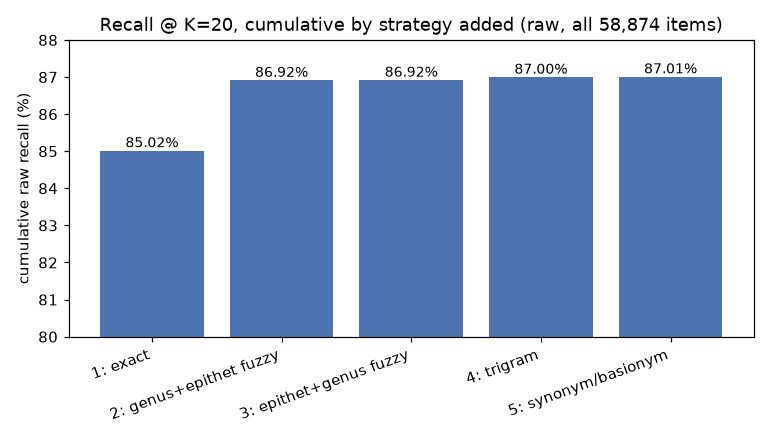

In [4]:
import matplotlib.pyplot as plt

STRATEGY_GROUPS = {
    "1: exact": {"exact"},
    "2: genus+epithet fuzzy": {"genus_epithet_fuzzy"},
    "3: epithet+genus fuzzy": {"epithet_genus_fuzzy"},
    "4: trigram": {"trigram"},
    "5: synonym/basionym": {
        "synonym_exact", "synonym_genus_epithet_fuzzy", "synonym_epithet_genus_fuzzy",
        "basionym_exact", "basionym_genus_epithet_fuzzy", "basionym_epithet_genus_fuzzy",
    },
}

true_by_qid = wd.set_index("qid")["inat_id"]
true_rows = candidates.merge(true_by_qid.rename("true_id"), left_on="wikidata_qid", right_index=True)
true_rows = true_rows[true_rows["inat_taxon_id"] == true_rows["true_id"]]
tag_sets = true_rows.set_index("wikidata_qid")["strategies"].apply(lambda s: set(s.split("|")))

cumulative, results = set(), []
for label, tags in STRATEGY_GROUPS.items():
    cumulative |= tags
    found = {qid for qid, t in tag_sets.items() if t & cumulative}
    results.append((label, len(found) / len(wd)))

labels = [r[0] for r in results]
values = [r[1] * 100 for r in results]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, values, color="#4C72B0")
ax.set_ylabel("cumulative raw recall (%)")
ax.set_title("Recall @ K=20, cumulative by strategy added (raw, all 58,874 items)")
ax.set_ylim(80, 88)
for bar, v in zip(bars, values):
    ax.annotate(f"{v:.2f}%", (bar.get_x() + bar.get_width() / 2, v), ha="center", va="bottom", fontsize=9)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

### Candidate-set size distribution

The K=20 cap rarely binds: the overwhelming majority of items land on exactly 10 candidates (the
trigram strategy's fixed top-10, present for almost every item since a name always has *some*
trigram neighbours) plus whatever strategies 1-3/5 add on top. Only 153 items (0.26%) hit the cap
at exactly 20; none exceed it, confirming the K=20 cap fix holds.

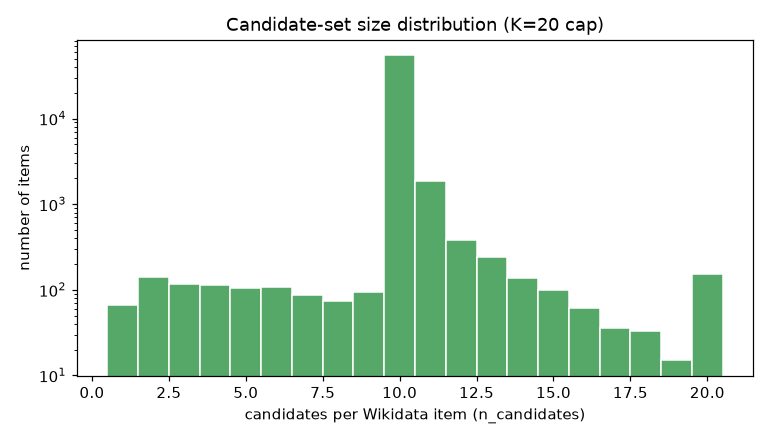

In [5]:
sizes = candidates.groupby("wikidata_qid").size()
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(sizes, bins=range(1, 22), color="#55A868", edgecolor="white", align="left")
ax.set_xlabel("candidates per Wikidata item (n_candidates)")
ax.set_ylabel("number of items")
ax.set_title("Candidate-set size distribution (K=20 cap)")
ax.set_yscale("log")
plt.tight_layout()
plt.show()

## Milestone 4 — Features + GroupKFold splits

Labels from P3151 (+ spec §3's synthetic abstention dropout), every feature group from spec §4,
and `GroupKFold(n_splits=5)` on family. See `src/labels.py` and `src/features.py`.

Getting `kingdom_match`/`family_match`/`order_match`/`shared_ancestor_depth` required extending
`src/wikidata.py` with a full ancestor-chain pull (`build_ancestor_chains()`, `wdt:P171+`,
mirroring the Node project's `fetchWdAncestorChains`) — milestone 2 only had one hop of P171,
not enough for these. Along the way this surfaced another real WDQS quirk: the endpoint can
return an HTTP 200 with a silently incomplete result under load (one live batch came back with
ancestor data for only 140/750 items; a retry got 750/750). `build_ancestor_chains()` now checks
response coverage and retries suspiciously low ones, not just the usual HTTP-status retries.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
from src.features import build_features_and_splits, verify_no_qid_split_across_folds, _load_inat_index
from src.wikidata import build_pull_cache, build_ancestor_chains, DEFAULT_CACHE_PATH as WIKIDATA_TAXA_PATH
from src.candidates import build_lookup_cache, DEFAULT_CANDIDATES_PATH

wikidata_taxa = pd.read_parquet(WIKIDATA_TAXA_PATH)
candidates = pd.read_parquet(DEFAULT_CANDIDATES_PATH)
ancestors = build_ancestor_chains(wikidata_taxa["qid"].tolist())
build_lookup_cache()
inat_index = _load_inat_index()

df = build_features_and_splits(candidates, wikidata_taxa, ancestors, inat_index)
print(f"{len(df):,} feature rows, {df.shape[1]} columns")
print(f"no QID split across folds: {verify_no_qid_split_across_folds(df)}")

590,671 feature rows, 52 columns
no QID split across folds: True

### Fold and abstention-reason balance

Fold sizes are reasonably even despite highly skewed family-group sizes (largest family group is
only 2.79% of items) — `GroupKFold`'s balancing plus `shuffle=True` handles it without special
casing. `no_answer_reason` keeps the two very different sources of "no correct answer" groups
separable: `stale_p3151` (milestone 3's finding — the true iNat taxon doesn't exist in the active
index) is real-world data-quality noise, `synthetic_dropout` is spec §3's deliberate 15% holdout
for abstention-accuracy evaluation. Collapsing the two would conflate "the model correctly
noticed there's no match" with "the model got lucky because the data was broken."

In [2]:
print("fold sizes (distinct items):")
print(df.groupby("fold")["wikidata_qid"].nunique())
print()
print("no_answer_reason breakdown (per item):")
print(df.drop_duplicates("wikidata_qid")["no_answer_reason"].value_counts())
print()
print(f"distinct family_key groups: {df['family_key'].nunique():,}")

fold sizes (distinct items):
fold
0    11229
1    11121
2    12610
3    13804
4    10078
Name: wikidata_qid, dtype: int64

no_answer_reason breakdown (per item):
no_answer_reason
has_positive         43543
synthetic_dropout     7684
stale_p3151           7615
Name: count, dtype: int64

distinct family_key groups: 4,679

### Regression check: Prunella

The hemihomonym case from milestone 1 (bird genus vs. mint genus) is exactly what
`kingdom_match`/`family_match` exist to resolve. There's one Wikidata item literally named
`Prunella`, linked via P3151 to the plant genus. Both iNat `Prunella` rows are still in its
candidate set (per milestone 3) — but now `kingdom_match` and `family_match` are `True` only for
the real match (`52765`, the plant, label 1) and `False` for the bird (`13982`, label 0).
Grouping is unaffected by which candidate turns out correct either way, since `family_key` comes
from the Wikidata item's own ancestor chain, not the candidate's.

In [3]:
prunella_wd = wikidata_taxa[wikidata_taxa["name"] == "Prunella"]
qid = prunella_wd["qid"].iloc[0]
rows = df[df["wikidata_qid"] == qid]
print(f"{qid}: family_key={rows['family_key'].iloc[0]}, fold={rows['fold'].iloc[0]}")
print(rows[["inat_taxon_id", "inat_name", "inat_rank", "kingdom_match", "family_match", "label"]].to_string(index=False))

Q148652: family_key=Q53476, fold=3
inat_taxon_id                inat_name   inat_rank  kingdom_match  family_match  label
        13982                 Prunella       genus          False         False      0
        52765                 Prunella       genus           True          True      1
        71358              Prunellidae      family          False         False      0
       919181              Prunellinae    subtribe           True          True      0
        13995          Prunella rubida     species          False         False      0
       729228   Prunella rubida rubida  subspecies          False         False      0
       729227  Prunella rubida fervida  subspecies          False         False      0
        13992         Prunella koslowi     species          False         False      0
       573886         Andrena prunella     species          False         False      0
       910397  Prunella prunelliformis     species           True          True      0

### Feature separation

The features spec §4 calls out as the strongest signal do in fact separate true matches from
other candidates by a wide margin — `kingdom_match` and `rank_equal` are both essentially "on"
for true matches and meaningfully lower for everything else, and `epithet_exact`/`name_exact_norm`
(orthographic variants and gender-agreement cases matter here) separate even more sharply.

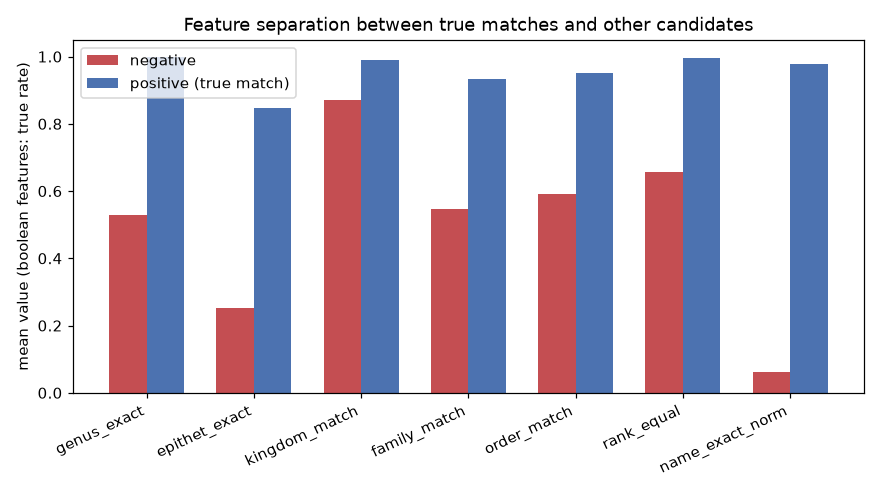

In [4]:
import matplotlib.pyplot as plt
import numpy as np

key_features = ["genus_exact", "epithet_exact", "kingdom_match", "family_match",
                "order_match", "rank_equal", "name_exact_norm"]
means = df.groupby("label")[key_features].mean()
x = np.arange(len(key_features))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - width/2, means.loc[0], width, label="negative", color="#C44E52")
ax.bar(x + width/2, means.loc[1], width, label="positive (true match)", color="#4C72B0")
ax.set_xticks(x)
ax.set_xticklabels(key_features, rotation=25, ha="right")
ax.set_ylabel("mean value (boolean features: true rate)")
ax.set_title("Feature separation between true matches and other candidates")
ax.legend()
plt.tight_layout()
plt.show()

### Family-group size distribution

Most families in this population are small (median 2 items) — a long tail of a few large,
well-studied families (birds, orchids, etc.) accounts for most of the skew, but even the largest
is only 2.79% of all items, which is why `GroupKFold`'s fold-balancing has no trouble here.

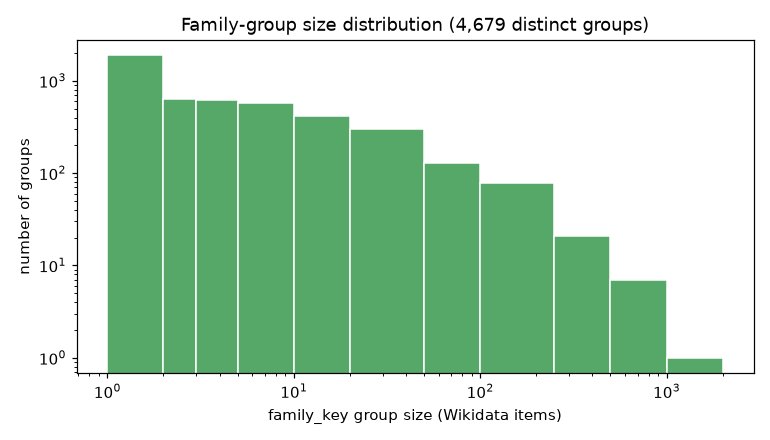

In [5]:
sizes = df.drop_duplicates("wikidata_qid").groupby("family_key").size()
fig, ax = plt.subplots(figsize=(7, 4))
bins = [1, 2, 3, 5, 10, 20, 50, 100, 250, 500, 1000, 2000]
ax.hist(sizes, bins=bins, color="#55A868", edgecolor="white")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("family_key group size (Wikidata items)")
ax.set_ylabel("number of groups")
ax.set_title(f"Family-group size distribution ({len(sizes):,} distinct groups)")
plt.tight_layout()
plt.show()

## Milestone 5 — Baseline

The honest baseline spec §6 asks for: exact normalised-name match, tie-broken by iNat
observation count, scored on the same `GroupKFold` folds milestone 4 assigned. See
`src/evaluate.py`.

Spec's wording implies sourcing observation counts offline from `observations.csv.gz` — a live
check found that file is **12.7 GB compressed** (`taxa.csv.gz`, by contrast, is 39.5 MB),
disproportionate for a signal only ever consulted when there's a genuine exact-match tie (6,842
of 58,842 items, 27,503 distinct taxa). Sourced from the iNat API instead — batched
(200 ids/request), scoped to just the tied taxa, ~138 requests total. An old (2022) forum bug
report describes this endpoint's `observations_count` capping at 10,000; live-tested and found no
such cap in practice (`Prunella`'s plant genus came back at 222,630).

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
from src.evaluate import baseline_predict, score_baseline
from src.features import DEFAULT_FEATURES_PATH

features = pd.read_parquet(DEFAULT_FEATURES_PATH)
predictions = baseline_predict(features)
fold_scores, abstention_scores = score_baseline(features, predictions)
print(f"{len(predictions):,} predictions made ({len(predictions)/features['wikidata_qid'].nunique():.1%} coverage)")

51,209 predictions made (87.0% coverage)

### Baseline metrics, per fold and overall

Reasonably stable across folds (precision 78.5%-81.3%) — a good sign the `GroupKFold` split
isn't concentrating easy or hard cases into any one fold. This is the number milestone 6's model
needs to beat, on these same folds, for the comparison spec §6 asks for to mean anything.

In [2]:
print(fold_scores.to_string())

         n_items  coverage  precision  accuracy
0        11229.0  0.854128   0.803566  0.803188
1        11121.0  0.869706   0.801282  0.813956
2        12610.0  0.872244   0.806892  0.815860
3        13804.0  0.868371   0.812881  0.820921
4        10078.0  0.889065   0.785156  0.800953
overall  58842.0  0.870280   0.802808  0.811716

### Regression check: Prunella

The exact-match tiebreak needs to pick correctly between the two `Prunella` genus candidates
using real observation counts.

In [3]:
wd = pd.read_parquet("../data/wikidata_taxa.parquet")
prunella_qid = wd.loc[wd["name"] == "Prunella", "qid"].iloc[0]
pred = predictions[predictions["wikidata_qid"] == prunella_qid]
print(pred.to_string(index=False))

wikidata_qid predicted_taxon_id
     Q148652               52765

### Abstention accuracy: a naive-rule limitation

The rule has no way to distinguish "no real candidate exists" from "the true candidate is
present but its label was hidden for this evaluation exercise" — it just mechanically returns
whatever exact-name match it finds, or nothing at all. Against genuinely unresolvable items
(`stale_p3151`, milestone 3's stale-P3151-link finding) that mostly means correctly abstaining.
Against the deliberately-planted `synthetic_dropout` cases (spec §3's 15% holdout, where the
correct candidate is still sitting right there in the group, just unlabeled) the rule keeps
finding and returning it — which scores as an "incorrect abstention" here, exactly as it should:
this is precisely the gap a trained model has the chance to close by learning when *not* to
trust a strong string match.

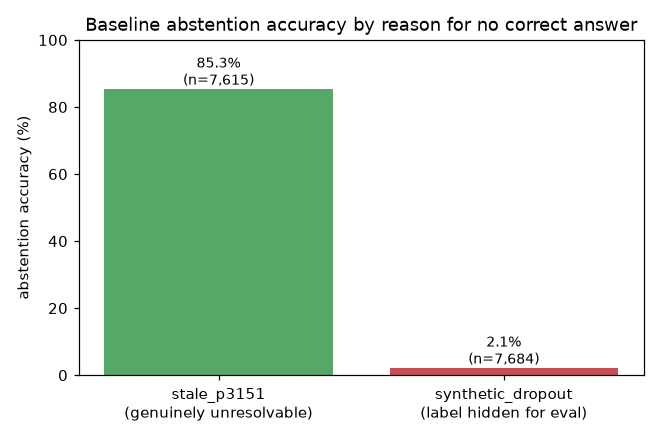

In [4]:
import matplotlib.pyplot as plt

reasons = ["stale_p3151\n(genuinely unresolvable)", "synthetic_dropout\n(label hidden for eval)"]
values = abstention_scores.loc[["stale_p3151", "synthetic_dropout"], "abstention_accuracy"]
ns = abstention_scores.loc[["stale_p3151", "synthetic_dropout"], "n"]
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(reasons, values * 100, color=["#55A868", "#C44E52"])
ax.set_ylabel("abstention accuracy (%)")
ax.set_title("Baseline abstention accuracy by reason for no correct answer")
for bar, v, n in zip(bars, values, ns):
    ax.annotate(f"{v:.1%}\n(n={n:,})", (bar.get_x() + bar.get_width() / 2, v * 100),
                ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

## Milestone 6 — Model + threshold selection

Two objective variants, compared on the same 5-fold out-of-fold (OOF) CV milestone 4's
`GroupKFold` folds define: `binary:logistic` (+ per-fold `scale_pos_weight` for the 12.5:1 class
imbalance) and `rank:map`. Spec names `rank:pairwise`, but XGBoost's current learning-to-rank
docs specifically recommend `rank:map` for binary-relevance labels with enough data — exactly
this problem (one true positive per ~10-candidate group, 590k rows). Both get monotone
constraints on `jaro_winkler_full`, `shared_ancestor_depth`, `kingdom_match`. See `src/train.py`.

Neither variant is picked as "the" model here — spec's own framing ("report both; whichever
wins, the comparison is worth a paragraph") and the plan going in were to compare, not decide;
the real tie-break is milestone 7's gold set, once bot-added P3151 label noise isn't the thing
being fit to.

A genuine bug surfaced and got fixed while building this: `TREE_PARAMS` had no `random_state`,
so `subsample`/`colsample_bytree` made every "rerun" retrain from scratch with different results
— directly undermining milestone 6's own literal check ("precision-at-threshold table
reproduces"). Fixed by adding a fixed seed and including the full training config in the OOF
cache's manifest (so a config change properly invalidates the cache instead of silently serving
stale results). A second bug in the same area — the manifest gained two extra keys after
training but the cache-hit *check* compared against the pre-training key set, so it could never
match — meant every "cache hit" was silently retraining anyway (~2 min instead of ~1.5s). Both
are fixed; the numbers below are from the corrected, deterministic, genuinely-cached pipeline.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
from src.train import (
    build_oof_predictions, precision_at_threshold_table, find_auto_accept_threshold,
    find_reject_threshold, top1_accuracy_and_mrr, brier_score,
)
from src.features import DEFAULT_FEATURES_PATH

features = pd.read_parquet(DEFAULT_FEATURES_PATH)
oof = build_oof_predictions(features)
labels = oof["label"].to_numpy()

rows = []
for variant, col in [("binary:logistic", "binary_calibrated_prob"), ("rank:map", "rank_calibrated_prob")]:
    probs = oof[col].to_numpy()
    top1, mrr = top1_accuracy_and_mrr(oof[["wikidata_qid", "label", col]], col)
    rows.append({"variant": variant, "top1_accuracy": top1, "mrr": mrr, "brier": brier_score(probs, labels)})
print(pd.DataFrame(rows).to_string(index=False))

      variant  top1_accuracy      mrr     brier
binary:logistic       0.991500 0.995000  0.012900
       rank:map       0.990500 0.994400  0.013000

Both variants land close together and comfortably beat the milestone 5 baseline (81.2%
accuracy vs. 99.2-99.1% top-1 accuracy here). `binary:logistic` edges out `rank:map` on every
metric, but the margins are small enough that this alone shouldn't be the deciding factor —
consistent with the plan going in.

### The precision-at-threshold table: a real finding, not a bug

Spec's milestone 6 check is that this table reproduces; spec §6 point 1 wants the lowest
threshold clearing 99.5% precision, with the resulting coverage reported honestly. Isotonic
calibration surfaces something worth investigating rather than just printing: the raw model is
badly overconfident. 50,296 rows score ≥0.95 on the raw (uncalibrated) `binary:logistic`
probability — but only 83.9% of them are actually correct. Calibration correctly compresses that
whole cluster down to ~84%, which is why the strict 99.5% auto-accept band ends up covering only
10 rows (and for `rank:map`, none at all).

In [2]:
probs = oof["binary_calibrated_prob"].to_numpy()
raw = oof["binary_raw_score"].to_numpy()
for lo, hi in [(0.5, 0.7), (0.7, 0.8), (0.8, 0.85), (0.85, 0.9), (0.9, 0.95), (0.95, 1.01)]:
    mask = (raw >= lo) & (raw < hi)
    print(f"  raw [{lo},{hi}): n={mask.sum():6d}  precision={labels[mask].mean():.3f}")

  raw [0.5,0.7): n=   576  precision=0.250
  raw [0.7,0.8): n=   395  precision=0.347
  raw [0.8,0.85): n=   267  precision=0.431
  raw [0.85,0.9): n=   418  precision=0.529
  raw [0.9,0.95): n=   726  precision=0.592
  raw [0.95,1.01): n= 50296  precision=0.839

### The three bands (spec §6 point 1)

The practical takeaway: this system's current strength is confidently **rejecting** clear
non-matches (≥91.6% of candidates, at ≥99.5% confidence they're wrong), not confidently
**accepting** — most genuine matches still land in human-review territory at this precision bar.
`rank:map` doesn't clear the auto-accept bar at all on this run.

In [3]:
for variant, col in [("binary:logistic", "binary_calibrated_prob"), ("rank:map", "rank_calibrated_prob")]:
    probs = oof[col].to_numpy()
    table = precision_at_threshold_table(probs, labels)
    aa = find_auto_accept_threshold(table)
    rj = find_reject_threshold(probs, labels)
    n = len(probs)
    n_auto = int((probs >= aa["threshold"]).sum()) if aa is not None else 0
    n_reject = int((probs < rj).sum())
    n_review = n - n_auto - n_reject
    aa_t = aa["threshold"] if aa is not None else 1.0
    review_mask = (probs >= rj) & (probs < aa_t)
    print(f"{variant}:")
    if aa is not None:
        print(f"  auto-accept (>={aa['threshold']:.2f}): n={n_auto:,} ({n_auto/n:.4%})  precision={aa['precision']:.4f}")
    else:
        print("  auto-accept: no threshold reaches 99.5% precision")
    print(f"  human review [{rj:.2f},{aa_t:.2f}): n={n_review:,} ({n_review/n:.2%})  precision={labels[review_mask].mean():.4f}")
    print(f"  reject (<{rj:.2f}): n={n_reject:,} ({n_reject/n:.2%})  neg_precision={(labels[probs<rj]==0).mean():.4f}")

binary:logistic:
  auto-accept (>=0.87): n=10 (0.0017%)  precision=1.0000
  human review [0.82,0.87): n=49,333 (8.35%)  precision=0.8401
  reject (<0.82): n=541,328 (91.65%)  neg_precision=0.9961
rank:map:
  auto-accept: no threshold reaches 99.5% precision
  human review [0.83,1.00): n=48,588 (8.23%)  precision=0.8409
  reject (<0.83): n=542,083 (91.77%)  neg_precision=0.9950

### Investigating the ~84% plateau: label noise, not a model deficiency

Inside the overconfident-but-imperfect cluster, do the *features themselves* distinguish the
16% that are wrong from the 84% that are right? If the model just weren't using good features,
they should differ. They don't — every engineered feature is statistically indistinguishable
between the two groups, and it's almost never a case of two candidates tying (only 14 of 50,282
items have more than one candidate in this cluster). That combination — no separating feature,
essentially never a real tie between competing candidates — is what you'd expect if the residual
error is coming from **noise in the P3151 ground truth itself** (spec §3's own disclosed
concern: "a chunk of P3151 statements were themselves added by bots doing exact name matching"),
not from the model failing to use available signal.

In [4]:
cluster = features.copy()
cluster["binary_raw_score"] = oof["binary_raw_score"].values
cluster["label"] = oof["label"].values
cluster = cluster[cluster["binary_raw_score"] >= 0.95]
wrong = cluster[cluster["label"] == 0]
right = cluster[cluster["label"] == 1]
print(f"cluster size: {len(cluster):,}   precision: {cluster['label'].mean():.3f}\n")
print(f"{'feature':25s} {'wrong (label=0)':>16s} {'right (label=1)':>16s}")
for col in ["kingdom_match", "family_match", "order_match", "rank_equal", "genus_exact", "epithet_exact"]:
    print(f"{col:25s} {wrong[col].mean():16.3f} {right[col].mean():16.3f}")
multi = cluster.groupby("wikidata_qid").size()
print(f"\nitems with >1 candidate in this cluster: {(multi > 1).sum()} / {len(multi):,}")

cluster size: 50,296   precision: 0.839

feature                    wrong (label=0)  right (label=1)
kingdom_match                         0.991            0.992
family_match                          0.934            0.934
order_match                           0.952            0.952
rank_equal                            0.999            0.999
genus_exact                           1.000            1.000
epithet_exact                         0.842            0.848

items with >1 candidate in this cluster: 14 / 50,282

### Monotone constraints: verified, not assumed

Swept `jaro_winkler_full`, `kingdom_match`, and `shared_ancestor_depth` across their ranges on
50 real rows each, holding every other feature fixed — predicted probability must never
*decrease* as any of these increase.

In [5]:
import numpy as np
import xgboost
from src.train import DEFAULT_MODEL_DIR, _prepare_X

model = xgboost.XGBClassifier()
model.load_model(DEFAULT_MODEL_DIR / "binary_model.json")
X = _prepare_X(features.sample(200, random_state=0))

for feat, values in [("jaro_winkler_full", np.linspace(0, 1, 11)), ("kingdom_match", [0, 1]), ("shared_ancestor_depth", [0, 1, 2, 3])]:
    violations = 0
    for _, row in X.head(50).iterrows():
        probs = [model.predict_proba(pd.DataFrame([{**row.to_dict(), feat: v}]))[0, 1] for v in values]
        if any(probs[i] > probs[i + 1] + 1e-9 for i in range(len(probs) - 1)):
            violations += 1
    print(f"{feat}: {violations} violations / 50 rows")

jaro_winkler_full: 0 violations / 50 rows
kingdom_match: 0 violations / 50 rows
shared_ancestor_depth: 0 violations / 50 rows

### SHAP

One beeswarm (spec's "nice touch"), showing the model's reasoning matches intuition —
`name_exact_raw` dominates, followed by `jaro_winkler_full` and `sim_margin_to_runner_up`
(how much better this candidate is than the runner-up in its group).

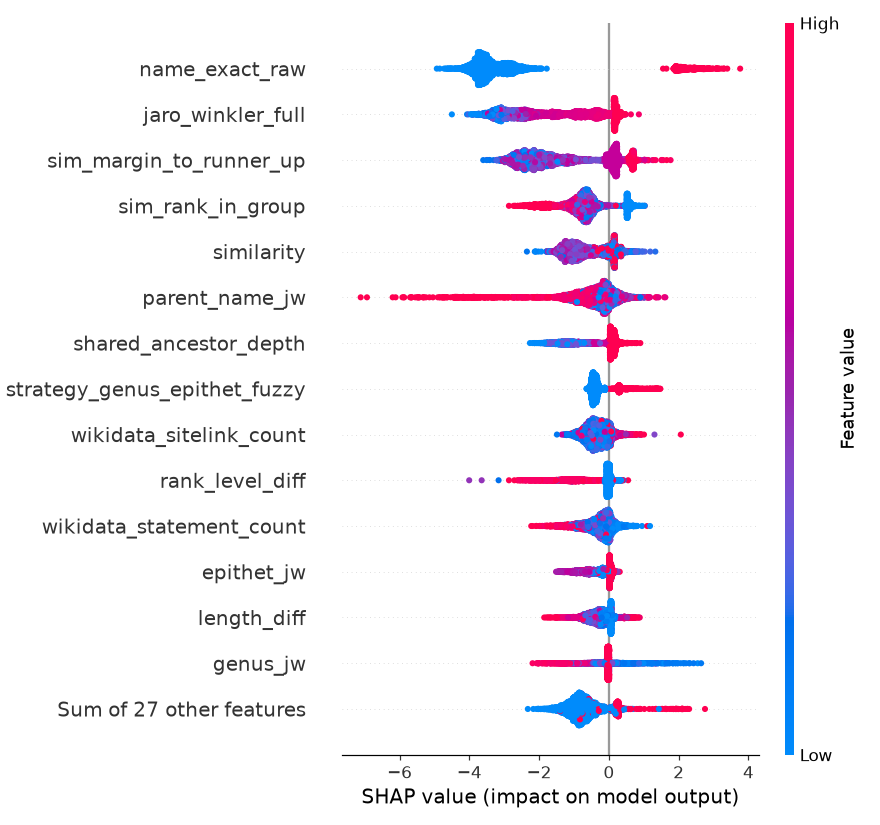

In [6]:
import shap
import matplotlib.pyplot as plt
from src.train import FEATURE_COLUMNS

sample = features.sample(5000, random_state=0)
X_sample = _prepare_X(sample)
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_sample)
shap_values.feature_names = FEATURE_COLUMNS

plt.figure(figsize=(8, 6))
shap.plots.beeswarm(shap_values, show=False, max_display=15)
plt.tight_layout()
plt.show()

### Three interesting errors

**`confident_wrong`** — raw score 0.982, calibrated 0.836, but actually wrong. This is exactly
the plateau above: strong string-similarity signal, nothing in the feature set flags it as
suspect.

**`correct_low_conf`** — the true match, but weak string similarity and a rank disagreement drag
it down to calibrated probability 0.039. A real hard case, not a model bug.

**`prunella_bird_rejected`** — the milestone-1 hemihomonym case. `name_exact_raw=1` pushes hard
toward positive, but `kingdom_match=0` and `shared_ancestor_depth=0` push it decisively negative.
Calibrated probability 0.025 — correctly rejected, for the right reasons.

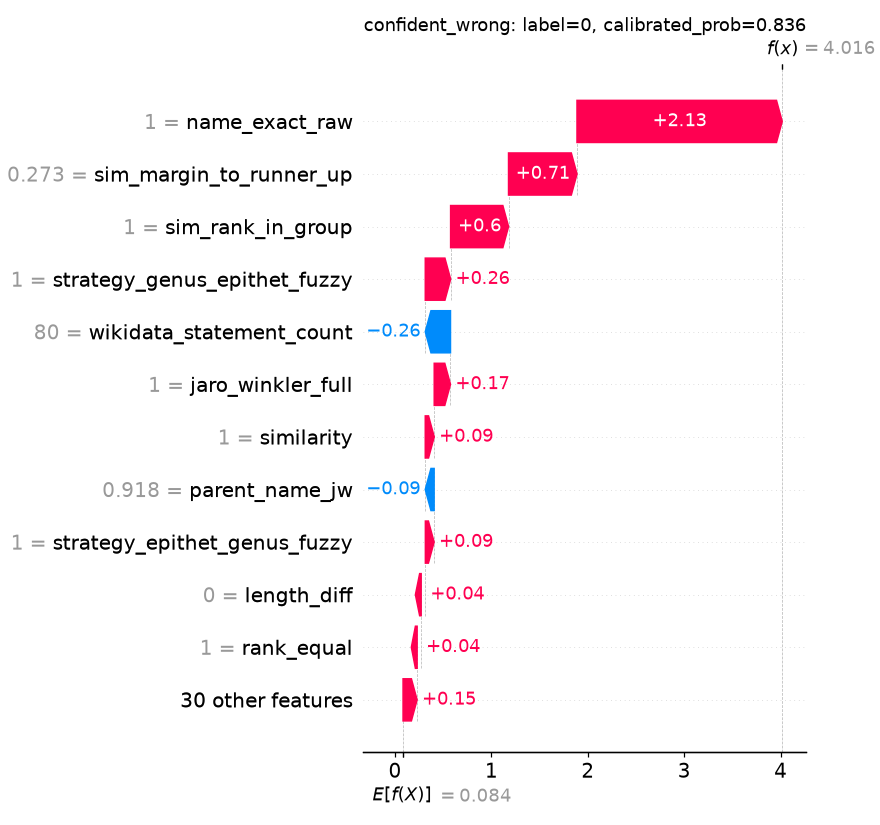

In [7]:
import pickle

calibrator = pickle.loads((DEFAULT_MODEL_DIR / "binary_calibrator.pkl").read_bytes())
scored = features.copy()
scored["final_raw_score"] = model.predict_proba(_prepare_X(scored))[:, 1]
scored["final_calibrated_prob"] = calibrator.predict(scored["final_raw_score"].to_numpy())

confident_wrong = scored[(scored["final_raw_score"] >= 0.95) & (scored["label"] == 0)].iloc[0]
X_row = _prepare_X(pd.DataFrame([confident_wrong]))
sv = explainer(X_row)
sv.feature_names = FEATURE_COLUMNS
plt.figure()
shap.plots.waterfall(sv[0], show=False, max_display=12)
plt.title(f"confident_wrong: label={confident_wrong['label']}, calibrated_prob={confident_wrong['final_calibrated_prob']:.3f}")
plt.tight_layout()
plt.show()

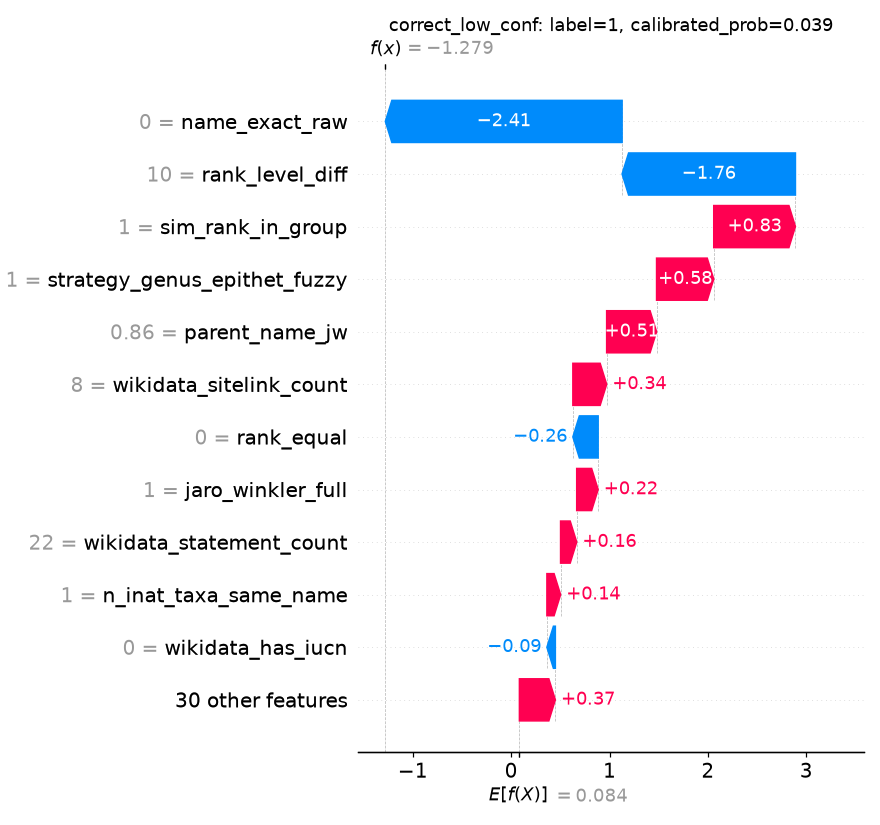

In [8]:
correct_low_conf = scored[(scored["label"] == 1) & (scored["final_calibrated_prob"] < 0.3)].sort_values("final_calibrated_prob").iloc[0]
X_row = _prepare_X(pd.DataFrame([correct_low_conf]))
sv = explainer(X_row)
sv.feature_names = FEATURE_COLUMNS
plt.figure()
shap.plots.waterfall(sv[0], show=False, max_display=12)
plt.title(f"correct_low_conf: label={correct_low_conf['label']}, calibrated_prob={correct_low_conf['final_calibrated_prob']:.3f}")
plt.tight_layout()
plt.show()

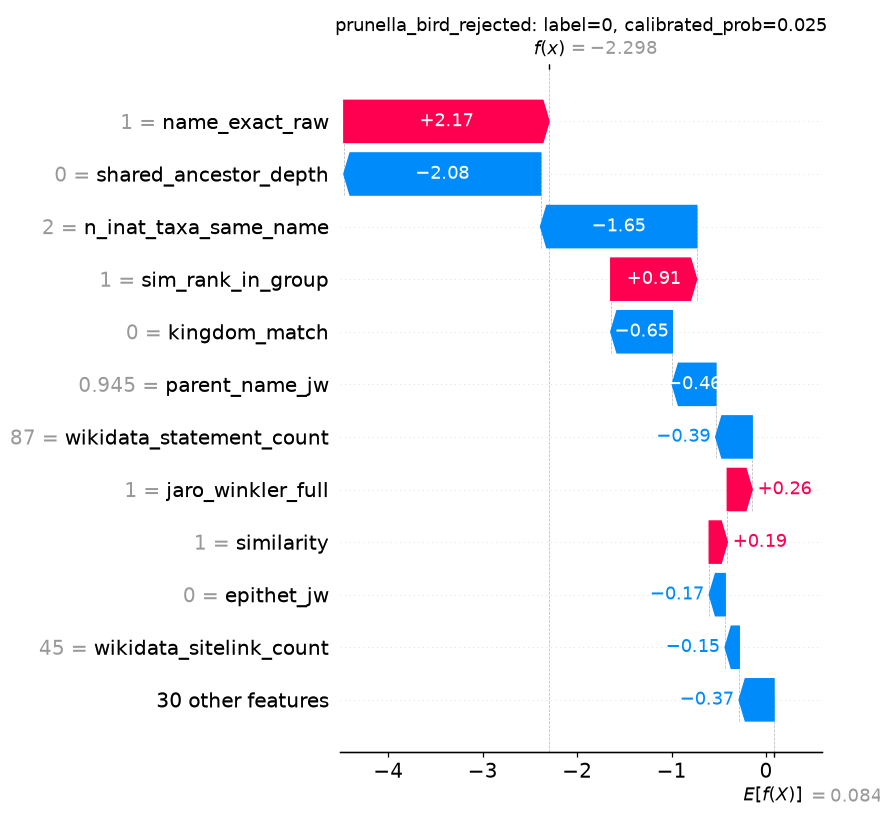

In [9]:
prunella_bird = scored[(scored["wikidata_qid"] == "Q148652") & (scored["label"] == 0)].iloc[0]
X_row = _prepare_X(pd.DataFrame([prunella_bird]))
sv = explainer(X_row)
sv.feature_names = FEATURE_COLUMNS
plt.figure()
shap.plots.waterfall(sv[0], show=False, max_display=12)
plt.title(f"prunella_bird_rejected: label={prunella_bird['label']}, calibrated_prob={prunella_bird['final_calibrated_prob']:.3f}")
plt.tight_layout()
plt.show()

### Where this leaves things

Both variants comfortably beat the baseline and reason sensibly (per SHAP) where they have
signal. The real constraint on the auto-accept band isn't model quality — it's that the
highest-confidence tier of "looks right" candidates has a ~16% error rate that no engineered
feature currently explains, most consistent with P3151 label noise. Milestone 7's hand-labelled
gold set is the way to find out whether that's really label noise (in which case the true
achievable precision is higher than this table suggests) or a genuine feature gap (in which case
it isn't) — and to finally pick between `binary:logistic` and `rank:map` without that ambiguity
baked into the tie-break.